# Chapter 5: Classical Simulation Methods

**Docker image**: `ml4t`

**Purpose**: Implement and compare classical Monte Carlo methods for generating
synthetic financial data, building the foundation for the learned generative
models that follow.

This notebook teaches the **mechanics** of established Monte Carlo methods for
generating synthetic financial data. We cover both the underlying mathematics
and practical implementation, then show library shortcuts for production use.

## Why Simulate?

Historical market data provides only **one path** through an infinite space of
possibilities. Simulation generates alternative scenarios for:

1. **Risk Management**: VaR, stress testing, tail risk assessment
2. **Backtesting**: Validate strategies beyond historical experience
3. **Data Augmentation**: Larger datasets for ML model training
4. **Privacy**: Share synthetic data without exposing proprietary signals

## Learning Objectives

After completing this notebook, you will be able to:

1. **Implement** each classical stochastic model from scratch
2. **Explain** the assumptions and limitations of each model
3. **Choose** the appropriate model for your use case
4. **Use** library implementations for production work

**Book Reference**: Chapter 5, Section 5.2 (Classical Simulation Baselines)

**Prerequisites**: Basic probability and stochastic processes; familiarity
with NumPy array operations. Requires ETF data from Chapter 2 (`load_etfs()`).

## Notebook Structure

1. **Part 1**: Continuous-Time Price Models (GBM, Jump-Diffusion, OU, Heston)
2. **Part 2**: Discrete-Time Volatility Model (GARCH with calibration)
3. **Part 3**: Bootstrap Methods (IID, Block, Stationary)
4. **Part 4**: Model Comparison

## Statistical Note

We use **log-returns** throughout for consistency with continuous-time SDEs:
- Log-return: $r_t = \ln(S_t / S_{t-1})$
- Kurtosis values are **Fisher (excess) kurtosis**: Gaussian = 0

## References

- Glasserman, P. (2003). "Monte Carlo Methods in Financial Engineering"
- Politis, D. & Romano, J. (1994). "The Stationary Bootstrap"
- Cont, R. (2001). "Empirical Properties of Asset Returns: Stylized Facts"
- Heston, S. (1993). "A Closed-Form Solution for Options with Stochastic Volatility"

In [1]:
"""Classical Simulation Methods - Educational implementation of stochastic models."""

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import seaborn as sns
from arch import arch_model
from arch.bootstrap import IIDBootstrap, MovingBlockBootstrap, StationaryBootstrap
from ml4t.data.providers import SyntheticProvider
from plotly.subplots import make_subplots
from scipy.stats import kurtosis, skew
from statsmodels.tsa.stattools import acf

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Production defaults (Papermill overrides for testing)
SEED = 42

In [3]:
set_global_seeds(SEED)

---
# Part 1: Continuous-Time Price Models

These models specify stochastic differential equations (SDEs) for price dynamics.
Each captures different market phenomena:

| Model | Key Feature | Best For |
|-------|-------------|----------|
| **GBM** | Log-normal prices, constant vol | Option pricing, baseline |
| **Jump-Diffusion** | Rare extreme moves | Crash scenarios, tail risk |
| **Mean-Reversion** | Prices drift to equilibrium | Spreads, commodities, rates |
| **Heston** | Stochastic volatility | Vol surfaces, leverage effect |

We implement each from scratch using local RNG for reproducibility,
then show the equivalent library call.

## 1.1 Geometric Brownian Motion (GBM)

The foundation of quantitative finance. Price $S$ follows the stochastic
differential equation:

$$dS = \mu S \, dt + \sigma S \, dW$$

where:
- $\mu$ = drift (expected annual return)
- $\sigma$ = volatility (annualized)
- $dW$ = Wiener process increment (Brownian motion)

### Key Properties

- **Log-returns are Gaussian**: $\ln(S_{t+1}/S_t) \sim N((\mu - \sigma^2/2)\Delta t, \sigma^2 \Delta t)$
- **Prices are log-normal**: Always positive, no crashes below zero
- **No memory**: Future returns independent of past (no autocorrelation)
- **Constant volatility**: Same vol every day (unrealistic)

### Discretization (Euler-Maruyama)

$$S_{t+\Delta t} = S_t \exp\left((\mu - \frac{\sigma^2}{2}) \Delta t + \sigma \sqrt{\Delta t} \, Z\right)$$

where $Z \sim N(0,1)$.

In [4]:
def simulate_gbm(
    n_steps: int,
    mu: float,
    sigma: float,
    S0: float = 100.0,
    dt: float = 1 / 252,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate Geometric Brownian Motion price path.

    Parameters
    ----------
    n_steps : int
        Number of time steps
    mu : float
        Annual drift (expected return)
    sigma : float
        Annual volatility
    S0 : float
        Initial price
    dt : float
        Time step (1/252 for daily)
    rng : np.random.Generator, optional
        Random number generator for reproducibility

    Returns
    -------
    np.ndarray
        Price path of length n_steps + 1
    """
    if rng is None:
        rng = np.random.default_rng()

    # Standard normal random draws
    Z = rng.standard_normal(n_steps)

    # Log-return for each step
    log_returns = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

    # Cumulative sum gives log-prices, then exponentiate
    log_prices = np.cumsum(log_returns)
    prices = S0 * np.exp(log_prices)

    # Prepend initial price
    return np.insert(prices, 0, S0)

### GBM Simulation

Generate 2 years of daily data and inspect the return distribution.

In [5]:
# Example: 2 years of daily data
gbm_rng = np.random.default_rng(42)
gbm_prices = simulate_gbm(n_steps=504, mu=0.08, sigma=0.20, rng=gbm_rng)
gbm_returns = np.diff(np.log(gbm_prices))

print(f"GBM simulation: {len(gbm_prices)} prices")
print(f"Annualized return: {gbm_returns.mean() * 252:.2%}")
print(f"Annualized volatility: {gbm_returns.std() * np.sqrt(252):.2%}")
print(f"Skewness: {skew(gbm_returns):.4f} (Gaussian: 0)")
print(f"Excess kurtosis: {kurtosis(gbm_returns, fisher=True, bias=False):.4f} (Gaussian: 0)")

GBM simulation: 505 prices
Annualized return: 1.89%
Annualized volatility: 19.22%
Skewness: 0.0909 (Gaussian: 0)
Excess kurtosis: -0.0640 (Gaussian: 0)


### Library Usage: GBM

The `ml4t-data` package provides production implementations via `SyntheticProvider`:

In [6]:
provider = SyntheticProvider(model="gbm", annual_return=0.08, annual_volatility=0.20, seed=42)
df = provider.fetch_ohlcv("SYNTH", "2022-01-01", "2023-12-31", "daily")
print(f"SyntheticProvider GBM: {len(df)} bars, final close={float(df['close'][-1]):.2f}")

2026-07-13 20:44:05 [debug    ] Rate limiter initialized       max_calls=1000 period=1.0 provider=synthetic


2026-07-13 20:44:05 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-07-13 20:44:05 [info     ] Fetching OHLCV data            end=2023-12-31 frequency=daily name=SyntheticProvider provider=synthetic start=2022-01-01 symbol=SYNTH


2026-07-13 20:44:05 [info     ] Generating 520 synthetic bars  frequency=daily model=gbm symbol=SYNTH


2026-07-13 20:44:05 [info     ] Successfully fetched OHLCV data name=SyntheticProvider provider=synthetic rows=520 symbol=SYNTH


SyntheticProvider GBM: 520 bars, final close=70.47


### GBM Limitations

GBM assumes returns are **i.i.d. Gaussian**, which contradicts observed
"stylized facts" of financial returns:

1. **Fat tails**: Real returns have excess kurtosis (more extremes than Gaussian)
2. **Volatility clustering**: High-vol days tend to follow high-vol days
3. **Leverage effect**: Negative returns often increase future volatility

Despite these limitations, GBM remains the workhorse for option pricing
(Black-Scholes) due to its analytical tractability.

## 1.2 Jump-Diffusion (Merton Model)

Adds occasional extreme moves to GBM via a compound Poisson process:

$$dS = \mu S \, dt + \sigma S \, dW + S(e^Y - 1) \, dN$$

where:
- $dN$ = Poisson process with intensity $\lambda$ (jumps per year)
- $Y \sim N(\mu_J, \sigma_J^2)$ = log jump size

### Drift Compensator

To ensure $\mu$ represents the *total* expected return (including jumps),
we subtract the expected jump contribution:

$$k = \mathbb{E}[e^Y - 1] = \exp(\mu_J + \tfrac{1}{2}\sigma_J^2) - 1$$

### Discretization

$$S_{t+\Delta t} = S_t \exp\left((\mu - \lambda k - \frac{\sigma^2}{2}) \Delta t
  + \sigma \sqrt{\Delta t} Z + \sum_{i=1}^{N_t} Y_i\right)$$

where $N_t \sim \text{Poisson}(\lambda \Delta t)$.

In [7]:
def simulate_jump_diffusion(
    n_steps: int,
    mu: float,
    sigma: float,
    lambda_: float,
    mu_jump: float,
    sigma_jump: float,
    S0: float = 100.0,
    dt: float = 1 / 252,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate Merton jump-diffusion price path with compensated drift.

    Parameters
    ----------
    n_steps : int
        Number of time steps
    mu : float
        Total annual drift (including jump contribution)
    sigma : float
        Annual volatility (diffusion part)
    lambda_ : float
        Jump intensity (expected jumps per year)
    mu_jump : float
        Mean of log jump size Y ~ N(mu_jump, sigma_jump^2)
    sigma_jump : float
        Std of log jump size
    S0 : float
        Initial price
    dt : float
        Time step
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    np.ndarray
        Price path of length n_steps + 1
    """
    if rng is None:
        rng = np.random.default_rng()

    # Jump compensator: E[e^Y - 1] so mu remains the total expected return
    k = np.exp(mu_jump + 0.5 * sigma_jump**2) - 1

    # Diffusion component with compensated drift
    Z = rng.standard_normal(n_steps)
    drift_compensated = mu - lambda_ * k - 0.5 * sigma**2
    diffusion = drift_compensated * dt + sigma * np.sqrt(dt) * Z

    # Jump component: compound Poisson
    N_jumps = rng.poisson(lambda_ * dt, n_steps)
    jump_component = np.zeros(n_steps)

    # Vectorized: for steps with jumps, sample and sum log jump sizes
    steps_with_jumps = np.where(N_jumps > 0)[0]
    for t in steps_with_jumps:
        jump_sizes = rng.normal(mu_jump, sigma_jump, N_jumps[t])
        jump_component[t] = np.sum(jump_sizes)

    # Combine and build price path
    log_returns = diffusion + jump_component
    log_prices = np.cumsum(log_returns)
    prices = S0 * np.exp(log_prices)

    return np.insert(prices, 0, S0)

### Jump-Diffusion Simulation

Simulate with negative jumps (crash scenarios). With `lambda_=5` we expect
roughly 5 jumps per year; `mu_jump=-0.03` means each jump averages 3% down.

In [8]:
# Example: negative jumps (crash scenarios)
# lambda=5 means ~5 jumps/year; mu_jump=-0.03 means avg 3% down-jump
jd_rng = np.random.default_rng(43)
jd_prices = simulate_jump_diffusion(
    n_steps=504,
    mu=0.08,  # Total expected return
    sigma=0.15,  # Diffusion volatility
    lambda_=5.0,
    mu_jump=-0.03,  # Mean log jump (negative = down)
    sigma_jump=0.04,
    rng=jd_rng,
)
jd_returns = np.diff(np.log(jd_prices))

# Show jump compensator
k = np.exp(-0.03 + 0.5 * 0.04**2) - 1
print(f"Jump-Diffusion simulation: {len(jd_prices)} prices")
print(f"Jump compensator k: {k:.4f} (subtracted from drift)")
print(f"Annualized return: {jd_returns.mean() * 252:.2%}")
print(f"Annualized volatility: {jd_returns.std() * np.sqrt(252):.2%}")
print(f"Skewness: {skew(jd_returns):.4f}")
print(f"Excess kurtosis: {kurtosis(jd_returns, fisher=True, bias=False):.4f} (> 0 from jumps)")

Jump-Diffusion simulation: 505 prices
Jump compensator k: -0.0288 (subtracted from drift)
Annualized return: 7.80%
Annualized volatility: 17.90%
Skewness: -1.5179
Excess kurtosis: 8.1871 (> 0 from jumps)


### Library Usage: Jump-Diffusion

In [9]:
provider = SyntheticProvider(model="gbm_jump", annual_return=0.08, annual_volatility=0.15, seed=43)
df = provider.fetch_ohlcv("SYNTH", "2022-01-01", "2023-12-31", "daily")
print(f"SyntheticProvider Jump-Diffusion: {len(df)} bars, final close={float(df['close'][-1]):.2f}")

2026-07-13 20:44:05 [debug    ] Rate limiter initialized       max_calls=1000 period=1.0 provider=synthetic


2026-07-13 20:44:05 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-07-13 20:44:05 [debug    ] HTTP session closed           


2026-07-13 20:44:05 [info     ] Fetching OHLCV data            end=2023-12-31 frequency=daily name=SyntheticProvider provider=synthetic start=2022-01-01 symbol=SYNTH


2026-07-13 20:44:05 [info     ] Generating 520 synthetic bars  frequency=daily model=gbm_jump symbol=SYNTH


2026-07-13 20:44:05 [info     ] Successfully fetched OHLCV data name=SyntheticProvider provider=synthetic rows=520 symbol=SYNTH


SyntheticProvider Jump-Diffusion: 520 bars, final close=105.15


## 1.3 Mean-Reversion (Ornstein-Uhlenbeck)

Prices gravitate toward a long-term equilibrium $\theta$:

$$d(\log S) = \kappa(\theta - \log S) \, dt + \sigma \, dW$$

where:
- $\kappa$ = speed of mean reversion
- $\theta$ = long-term mean (log-price level)
- Half-life: $t_{1/2} = \ln(2) / \kappa$

### Key Properties

- **Stationary**: Prices fluctuate around equilibrium
- **No trends**: Can't capture bull/bear markets
- **Negative autocorrelation**: Today's move partially reversed tomorrow

### Discretization Options

**Euler-Maruyama** (approximate):
$$X_{t+\Delta t} = X_t + \kappa(\theta - X_t)\Delta t + \sigma\sqrt{\Delta t} Z$$

**Exact transition** (closed-form for OU):
$$X_{t+\Delta t} = \theta + (X_t - \theta)e^{-\kappa\Delta t}
  + \sigma\sqrt{\frac{1 - e^{-2\kappa\Delta t}}{2\kappa}} Z$$

We implement both to compare discretization error.

In [10]:
def simulate_mean_reversion_euler(
    n_steps: int,
    kappa: float,
    theta: float,
    sigma: float,
    S0: float = 100.0,
    dt: float = 1 / 252,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate OU process using Euler-Maruyama discretization.

    Parameters
    ----------
    n_steps : int
        Number of time steps
    kappa : float
        Mean reversion speed (annualized)
    theta : float
        Long-term mean (log-price level)
    sigma : float
        Volatility (annualized)
    S0 : float
        Initial price
    dt : float
        Time step
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    np.ndarray
        Price path of length n_steps + 1
    """
    if rng is None:
        rng = np.random.default_rng()

    log_prices = np.zeros(n_steps + 1)
    log_prices[0] = np.log(S0)

    Z = rng.standard_normal(n_steps)

    for t in range(n_steps):
        log_prices[t + 1] = (
            log_prices[t] + kappa * (theta - log_prices[t]) * dt + sigma * np.sqrt(dt) * Z[t]
        )

    return np.exp(log_prices)

### Exact Transition Density

The OU process has a closed-form transition density, eliminating
discretization error entirely. We implement both to compare accuracy.

In [11]:
def simulate_mean_reversion_exact(
    n_steps: int,
    kappa: float,
    theta: float,
    sigma: float,
    S0: float = 100.0,
    dt: float = 1 / 252,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate OU process using exact transition density.

    The exact solution eliminates discretization error entirely.
    """
    if rng is None:
        rng = np.random.default_rng()

    log_prices = np.zeros(n_steps + 1)
    log_prices[0] = np.log(S0)

    # Precompute constants
    exp_neg_kappa_dt = np.exp(-kappa * dt)
    std_dev = sigma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa))

    Z = rng.standard_normal(n_steps)

    for t in range(n_steps):
        log_prices[t + 1] = theta + (log_prices[t] - theta) * exp_neg_kappa_dt + std_dev * Z[t]

    return np.exp(log_prices)

### Mean-Reversion Simulation

Compare exact vs Euler discretization. With `kappa=2`, the half-life is
$\ln(2)/2 \approx 0.35$ years (87 trading days).

In [12]:
# Example: mean-reverting around 100 using exact discretization
# kappa=2 gives half-life of ln(2)/2 ≈ 0.35 years (87 trading days)
mr_rng = np.random.default_rng(44)
mr_prices = simulate_mean_reversion_exact(
    n_steps=504,
    kappa=2.0,
    theta=np.log(100),  # Long-term mean at 100
    sigma=0.15,
    rng=mr_rng,
)
mr_returns = np.diff(np.log(mr_prices))

half_life_days = np.log(2) / 2.0 * 252
print(f"Mean-Reversion (exact) simulation: {len(mr_prices)} prices")
print(f"Half-life: {half_life_days:.0f} trading days")
print(f"Final price: {mr_prices[-1]:.2f} (equilibrium: 100)")
print(f"Return autocorr(1): {np.corrcoef(mr_returns[:-1], mr_returns[1:])[0, 1]:.4f}")

# Compare Euler vs Exact discretization
mr_rng_euler = np.random.default_rng(44)  # Same seed
mr_euler = simulate_mean_reversion_euler(
    n_steps=504, kappa=2.0, theta=np.log(100), sigma=0.15, rng=mr_rng_euler
)
max_diff = np.max(np.abs(mr_prices - mr_euler))
print(f"Euler vs Exact max difference: {max_diff:.6f}")

Mean-Reversion (exact) simulation: 505 prices
Half-life: 87 trading days
Final price: 99.60 (equilibrium: 100)
Return autocorr(1): -0.0615
Euler vs Exact max difference: 0.047112


### Library Usage: Mean-Reversion

In [13]:
provider = SyntheticProvider(model="mean_revert", annual_volatility=0.15, seed=44)
df = provider.fetch_ohlcv("SYNTH", "2022-01-01", "2023-12-31", "daily")
print(f"SyntheticProvider Mean-Revert: {len(df)} bars, final close={float(df['close'][-1]):.2f}")

2026-07-13 20:44:05 [debug    ] Rate limiter initialized       max_calls=1000 period=1.0 provider=synthetic


2026-07-13 20:44:05 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-07-13 20:44:05 [debug    ] HTTP session closed           


2026-07-13 20:44:05 [info     ] Fetching OHLCV data            end=2023-12-31 frequency=daily name=SyntheticProvider provider=synthetic start=2022-01-01 symbol=SYNTH


2026-07-13 20:44:05 [info     ] Generating 520 synthetic bars  frequency=daily model=mean_revert symbol=SYNTH


2026-07-13 20:44:05 [info     ] Successfully fetched OHLCV data name=SyntheticProvider provider=synthetic rows=520 symbol=SYNTH


SyntheticProvider Mean-Revert: 520 bars, final close=95.94


## 1.4 Heston (Stochastic Volatility)

Volatility itself is random, following a separate mean-reverting process:

$$dS = \mu S \, dt + \sqrt{v} S \, dW_S$$
$$dv = \kappa(\theta - v) \, dt + \xi \sqrt{v} \, dW_v$$
$$\text{Corr}(dW_S, dW_v) = \rho$$

where:
- $v$ = instantaneous variance
- $\kappa$ = variance mean-reversion speed
- $\theta$ = long-term variance
- $\xi$ = volatility of volatility ("vol of vol")
- $\rho$ = correlation between price and variance shocks (leverage effect)

### Key Properties

- **Stochastic volatility**: Vol changes unpredictably
- **Leverage effect**: $\rho < 0$ means price drops increase volatility
- **Fat tails**: From randomness in volatility
- **Volatility clustering**: From mean-reversion in variance
- **Feller condition**: $2\kappa\theta > \xi^2$ prevents variance from hitting zero

### Discretization: Full Truncation Euler

To handle potential negative variance, we use **full truncation**:
apply $\max(v, 0)$ consistently in both drift and diffusion terms.

In [14]:
def simulate_heston(
    n_steps: int,
    mu: float,
    v0: float,
    kappa: float,
    theta: float,
    xi: float,
    rho: float,
    S0: float = 100.0,
    dt: float = 1 / 252,
    rng: np.random.Generator | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate Heston stochastic volatility path using full truncation Euler.

    Full truncation applies max(v, 0) to the current variance before
    computing both drift and diffusion terms, ensuring consistency.

    Parameters
    ----------
    n_steps : int
        Number of time steps
    mu : float
        Drift
    v0 : float
        Initial variance
    kappa : float
        Variance mean-reversion speed
    theta : float
        Long-term variance
    xi : float
        Volatility of variance (vol of vol)
    rho : float
        Correlation between price and variance shocks
    S0 : float
        Initial price
    dt : float
        Time step
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Price path and variance path

    Note
    ----
    For production use, consider Andersen's QE scheme which has better
    accuracy near the boundary.
    """
    if rng is None:
        rng = np.random.default_rng()

    prices = np.zeros(n_steps + 1)
    variance = np.zeros(n_steps + 1)
    prices[0] = S0
    variance[0] = v0

    sqrt_dt = np.sqrt(dt)

    for t in range(n_steps):
        # Full truncation: apply floor BEFORE computing terms
        v_t = max(variance[t], 0)
        sqrt_v_t = np.sqrt(v_t)

        # Correlated Brownian motions
        Z1 = rng.standard_normal()
        Z2 = rng.standard_normal()
        W_v = Z1
        W_S = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        # Variance update (full truncation Euler)
        variance[t + 1] = v_t + kappa * (theta - v_t) * dt + xi * sqrt_v_t * sqrt_dt * W_v
        # Floor the result for next iteration
        variance[t + 1] = max(variance[t + 1], 0)

        # Price update
        prices[t + 1] = prices[t] * np.exp((mu - 0.5 * v_t) * dt + sqrt_v_t * sqrt_dt * W_S)

    return prices, variance

### Heston Simulation

Simulate with typical parameters. We verify the Feller condition
($2\kappa\theta > \xi^2$) to ensure variance stays positive.

In [15]:
# Example: typical Heston parameters
# Feller condition: 2*5*0.04 = 0.4 > 0.3^2 = 0.09 [OK]
heston_rng = np.random.default_rng(45)
heston_prices, heston_var = simulate_heston(
    n_steps=504,
    mu=0.05,
    v0=0.04,  # Initial vol = 20%
    kappa=5.0,  # Fast mean reversion
    theta=0.04,  # Long-term vol = 20%
    xi=0.3,  # Vol of vol = 30%
    rho=-0.7,  # Strong leverage effect
    rng=heston_rng,
)
heston_returns = np.diff(np.log(heston_prices))

# Verify Feller condition
feller_lhs = 2 * 5.0 * 0.04
feller_rhs = 0.3**2
print(f"Heston simulation: {len(heston_prices)} prices")
print(
    f"Feller condition: 2*kappa*theta = {feller_lhs:.2f} > xi^2 = {feller_rhs:.2f}: "
    f"{'OK' if feller_lhs > feller_rhs else 'VIOLATED'}"
)
print(f"Initial vol: {np.sqrt(heston_var[0]) * 100:.1f}%")
print(f"Final vol: {np.sqrt(heston_var[-1]) * 100:.1f}%")
print(f"Min variance (should be >= 0): {heston_var.min():.6f}")
print(f"Excess kurtosis: {kurtosis(heston_returns, fisher=True, bias=False):.4f}")

Heston simulation: 505 prices
Feller condition: 2*kappa*theta = 0.40 > xi^2 = 0.09: OK
Initial vol: 20.0%
Final vol: 15.7%
Min variance (should be >= 0): 0.006035
Excess kurtosis: 0.9388


### Library Usage: Heston

In [16]:
provider = SyntheticProvider(model="heston", annual_volatility=0.20, heston_xi=0.3, seed=45)
df = provider.fetch_ohlcv("SYNTH", "2022-01-01", "2023-12-31", "daily")
print(f"SyntheticProvider Heston: {len(df)} bars, final close={float(df['close'][-1]):.2f}")

2026-07-13 20:44:05 [debug    ] Rate limiter initialized       max_calls=1000 period=1.0 provider=synthetic


2026-07-13 20:44:05 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-07-13 20:44:05 [debug    ] HTTP session closed           


2026-07-13 20:44:05 [info     ] Fetching OHLCV data            end=2023-12-31 frequency=daily name=SyntheticProvider provider=synthetic start=2022-01-01 symbol=SYNTH


2026-07-13 20:44:05 [info     ] Generating 520 synthetic bars  frequency=daily model=heston symbol=SYNTH


2026-07-13 20:44:05 [info     ] Successfully fetched OHLCV data name=SyntheticProvider provider=synthetic rows=520 symbol=SYNTH


SyntheticProvider Heston: 520 bars, final close=145.87


---
# Part 2: Discrete-Time Volatility Model (GARCH)

Unlike the continuous-time SDEs above, GARCH is a **discrete-time model**
for conditional variance. It models how return volatility evolves based on
past shocks.

## GARCH(1,1)

$$r_t = \mu + \sigma_t \varepsilon_t, \quad \varepsilon_t \sim N(0,1)$$
$$\sigma^2_t = \omega + \alpha (r_{t-1} - \mu)^2 + \beta \sigma^2_{t-1}$$

where:
- $\mu$ = unconditional mean return (drift)
- $\omega$ = base variance (intercept)
- $\alpha$ = reaction to recent shocks (news impact)
- $\beta$ = persistence of past variance (memory)
- $\alpha + \beta < 1$ required for stationarity

### Key Properties

- **Volatility clustering**: $\beta > 0$ means vol persists
- **Fat tails**: From time-varying volatility
- **Mean-reverting volatility**: Unconditional variance = $\omega / (1 - \alpha - \beta)$
- **Leverage effect**: Requires asymmetric extensions (GJR-GARCH, EGARCH)

### GARCH vs Heston

| Aspect | GARCH | Heston |
|--------|-------|--------|
| Time | Discrete | Continuous |
| Leverage | Extensions needed | Built-in ($\rho$) |
| Calibration | MLE from data | Option surface |
| Analytical | Limited | Semi-closed form |

## Calibration: Fitting GARCH to Data

Unlike SDEs where we **choose** parameters (drift, volatility), GARCH is
typically **fitted** to historical data via maximum likelihood estimation.

In [17]:
# Load SPY returns for GARCH calibration
etf_data = load_etfs()
spy_close = (
    etf_data.filter(pl.col("symbol") == "SPY")
    .sort("timestamp")
    .select("close")
    .to_series()
    .to_numpy()
)

# Compute log returns in percent (arch library convention; matches exp(cumsum) reconstruction)
spy_log_returns_pct = np.diff(np.log(spy_close)) * 100

print(f"SPY log-returns: {len(spy_log_returns_pct)} observations")
print(f"Mean: {spy_log_returns_pct.mean():.4f}% daily")
print(f"Std: {spy_log_returns_pct.std():.4f}%")

SPY log-returns: 5030 observations
Mean: 0.0408% daily
Std: 1.2220%


### Fit GARCH(1,1) to SPY

In [18]:
# Fit GARCH(1,1) model
am = arch_model(spy_log_returns_pct, mean="Constant", vol="GARCH", p=1, q=1)
res = am.fit(disp="off")

# Extract calibrated parameters
mu_fit = res.params["mu"]
omega_fit = res.params["omega"]
alpha_fit = res.params["alpha[1]"]
beta_fit = res.params["beta[1]"]

print("Calibrated GARCH(1,1) parameters:")
print(f"  mu (mean):     {mu_fit:.6f}% daily")
print(f"  omega:         {omega_fit:.6f}")
print(f"  alpha (news):  {alpha_fit:.4f}")
print(f"  beta (memory): {beta_fit:.4f}")
print(f"  persistence:   {alpha_fit + beta_fit:.4f}")
print(f"  unconditional vol: {np.sqrt(omega_fit / (1 - alpha_fit - beta_fit)):.4f}% daily")

Calibrated GARCH(1,1) parameters:
  mu (mean):     0.081175% daily
  omega:         0.030613
  alpha (news):  0.1404
  beta (memory): 0.8362
  persistence:   0.9766
  unconditional vol: 1.1450% daily


### Simulate from Calibrated Parameters

Now we can simulate new paths using the fitted parameters.

In [19]:
def simulate_garch(
    n_steps: int,
    mu: float,
    omega: float,
    alpha: float,
    beta: float,
    sigma0: float | None = None,
    rng: np.random.Generator | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate GARCH(1,1) return series with mean.

    Parameters
    ----------
    n_steps : int
        Number of time steps
    mu : float
        Mean return (same units as omega)
    omega : float
        Base variance (intercept)
    alpha : float
        Shock coefficient (news impact)
    beta : float
        Persistence coefficient
    sigma0 : float, optional
        Initial volatility. If None, use unconditional volatility.
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Returns and volatility paths
    """
    if rng is None:
        rng = np.random.default_rng()

    # Unconditional variance
    uncond_var = omega / (1 - alpha - beta)
    if sigma0 is None:
        sigma0 = np.sqrt(uncond_var)

    returns = np.zeros(n_steps)
    sigma = np.zeros(n_steps)
    sigma[0] = sigma0

    for t in range(n_steps):
        # Generate return with mean
        eps = rng.standard_normal()
        returns[t] = mu + sigma[t] * eps

        # Update volatility for next period
        if t < n_steps - 1:
            shock = returns[t] - mu  # Deviation from mean
            sigma[t + 1] = np.sqrt(omega + alpha * shock**2 + beta * sigma[t] ** 2)

    return returns, sigma

### GARCH Simulation from Calibrated Parameters

Use the fitted SPY parameters to generate a synthetic path and compare
the resulting moments with the calibrated values.

In [20]:
# Simulate using calibrated parameters
garch_rng = np.random.default_rng(46)
garch_log_returns_pct, garch_vol = simulate_garch(
    n_steps=504,
    mu=mu_fit,
    omega=omega_fit,
    alpha=alpha_fit,
    beta=beta_fit,
    rng=garch_rng,
)

# Convert to prices (from log returns in percent)
garch_log_returns = garch_log_returns_pct / 100  # Convert to decimal log returns
garch_prices = 100 * np.exp(np.cumsum(np.insert(garch_log_returns, 0, 0)))

print(f"GARCH simulation (calibrated to SPY): {len(garch_prices)} prices")
print(f"Simulated annual return: {garch_log_returns.mean() * 252:.2%}")
print(f"Simulated annual vol: {garch_log_returns.std() * np.sqrt(252):.1%}")
print(f"Excess kurtosis: {kurtosis(garch_log_returns, fisher=True, bias=False):.4f}")

GARCH simulation (calibrated to SPY): 505 prices
Simulated annual return: 15.02%
Simulated annual vol: 15.8%
Excess kurtosis: 2.6772


### Library Usage: GARCH

In [21]:
provider = SyntheticProvider(
    model="garch",
    garch_omega=omega_fit,
    garch_alpha=alpha_fit,
    garch_beta=beta_fit,
    seed=46,
)
df = provider.fetch_ohlcv("SYNTH", "2022-01-01", "2023-12-31", "daily")
print(f"SyntheticProvider GARCH: {len(df)} bars, final close={float(df['close'][-1]):.2f}")

2026-07-13 20:44:05 [debug    ] Rate limiter initialized       max_calls=1000 period=1.0 provider=synthetic


2026-07-13 20:44:05 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-07-13 20:44:05 [debug    ] HTTP session closed           


2026-07-13 20:44:05 [info     ] Fetching OHLCV data            end=2023-12-31 frequency=daily name=SyntheticProvider provider=synthetic start=2022-01-01 symbol=SYNTH


2026-07-13 20:44:05 [info     ] Generating 520 synthetic bars  frequency=daily model=garch symbol=SYNTH


2026-07-13 20:44:05 [info     ] Successfully fetched OHLCV data name=SyntheticProvider provider=synthetic rows=520 symbol=SYNTH


SyntheticProvider GARCH: 520 bars, final close=136.49


---
## Visualize All Parametric Models

In [22]:
# Collect all simulations
all_models = {
    "GBM": gbm_prices,
    "Jump-Diffusion": jd_prices,
    "Mean-Reversion": mr_prices,
    "Heston": heston_prices,
    "GARCH": garch_prices,
}

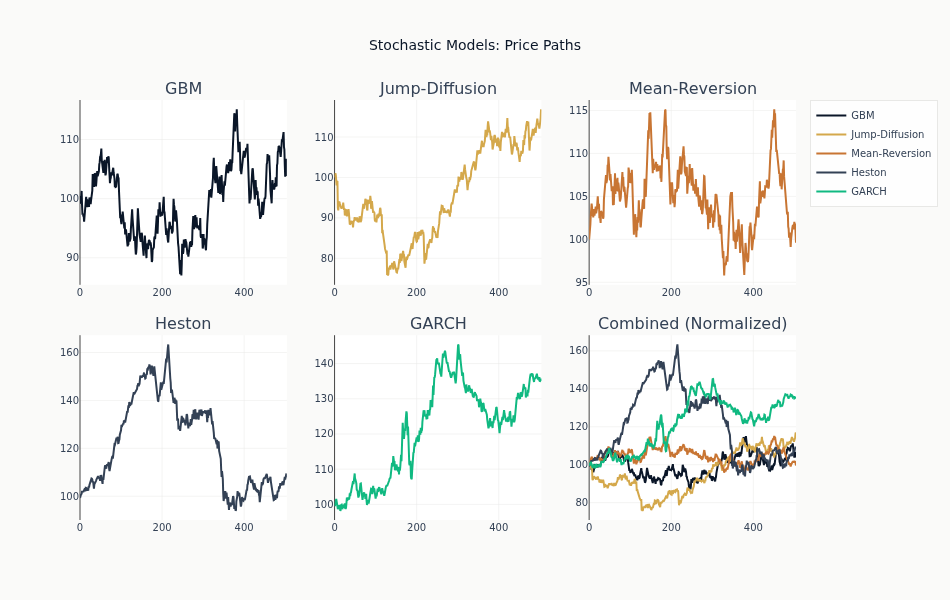

In [23]:
# Create comparison plot
fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=list(all_models.keys()) + ["Combined (Normalized)"],
    vertical_spacing=0.12,
)

colors = [COLORS["blue"], COLORS["amber"], COLORS["copper"], COLORS["neutral"], COLORS["positive"]]

# Individual plots (no legend - subplot titles identify each)
for idx, (name, prices) in enumerate(all_models.items()):
    row, col = (idx // 3) + 1, (idx % 3) + 1
    fig.add_trace(
        go.Scatter(
            y=prices, mode="lines", name=name, line=dict(color=colors[idx]), showlegend=False
        ),
        row=row,
        col=col,
    )

# Combined normalized plot (with legend for comparison)
for idx, (name, prices) in enumerate(all_models.items()):
    normalized = 100 * prices / prices[0]
    fig.add_trace(
        go.Scatter(y=normalized, mode="lines", name=name, line=dict(color=colors[idx])),
        row=2,
        col=3,
    )

fig.update_layout(
    title_text="Stochastic Models: Price Paths",
    height=600,
    width=950,
)
fig.show()

### Normalized Price Paths (Grayscale-Compatible)

A matplotlib companion to the plotly grid above, using distinct line styles
that remain distinguishable in grayscale print.

/tmp/ipykernel_1693132/2517849336.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


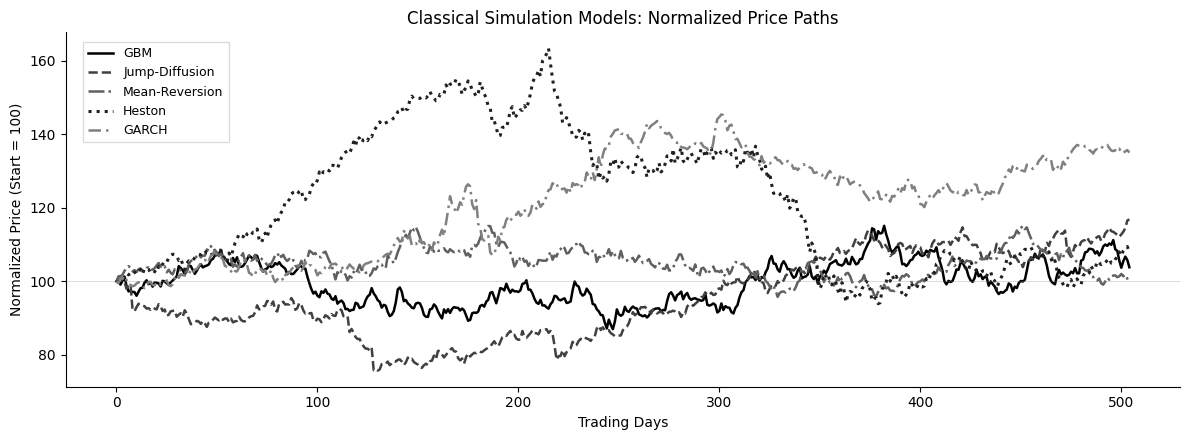

In [24]:
# Line styles for grayscale compatibility - varied grays + distinct patterns
LINE_STYLES = [
    {"linestyle": "-", "linewidth": 1.8, "color": "black"},  # GBM: solid black
    {"linestyle": "--", "linewidth": 1.8, "color": "#404040"},  # Jump-Diffusion: dashed dark gray
    {
        "linestyle": "-.",
        "linewidth": 1.8,
        "color": "#606060",
    },  # Mean-Reversion: dash-dot medium gray
    {"linestyle": ":", "linewidth": 2.2, "color": "#202020"},  # Heston: dotted near-black (thicker)
    {
        "linestyle": (0, (5, 2, 1, 2)),
        "linewidth": 1.8,
        "color": "#808080",
    },  # GARCH: long-dash-dot gray
]

# Create wide-format figure (at least 2:1 aspect ratio). Build and style
# in a SINGLE cell so the inline backend does not flush the figure mid-
# construction with no title / labels / legend
# (feedback_split_cell_figure_bug).
fig, ax = plt.subplots(figsize=(12, 4.5))

# Plot each model normalized to 100
for idx, (name, prices) in enumerate(all_models.items()):
    normalized = 100 * prices / prices[0]
    ax.plot(normalized, label=name, **LINE_STYLES[idx])

# Styling
ax.set_xlabel("Trading Days")
ax.set_ylabel("Normalized Price (Start = 100)")
ax.set_title("Classical Simulation Models: Normalized Price Paths")

# Legend outside plot area to avoid overlap
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    frameon=True,
    fancybox=False,
    edgecolor="lightgray",
    fontsize=9,
)

# Add horizontal reference line at 100
ax.axhline(y=100, color="gray", linewidth=0.5, linestyle="-", alpha=0.4)

# Despine (seaborn style)
sns.despine(ax=ax)

# Tight layout
fig.tight_layout()
fig.show()

**Interpretation**: GBM produces the smoothest paths — a direct consequence of
continuous diffusion with constant volatility. Jump-diffusion adds sudden
discontinuities mimicking flash crashes or earnings surprises. Heston's
stochastic volatility creates volatility clustering: calm periods punctuated
by turbulent episodes. GARCH captures similar clustering in discrete time,
while mean-reversion pulls prices back toward equilibrium. The normalized
comparison (bottom right) shows models diverge most during high-volatility
regimes — precisely where model choice matters most for risk estimation.

## Model Statistics Comparison

Compute standardized metrics across all parametric models to quantify how
each captures (or fails to capture) empirical stylized facts: fat tails
(excess kurtosis), asymmetry (skewness), and drawdown behavior.

In [25]:
def compute_model_stats(prices: np.ndarray, name: str) -> dict:
    """Compute key statistics for a price path using log-returns."""
    log_returns = np.diff(np.log(prices))
    return {
        "model": name,
        "annual_return": log_returns.mean() * 252,
        "annual_volatility": log_returns.std() * np.sqrt(252),
        "skewness": skew(log_returns),
        "excess_kurtosis": kurtosis(log_returns, fisher=True, bias=False),
        "max_drawdown": np.min(prices / np.maximum.accumulate(prices) - 1),
    }


stats_rows = [compute_model_stats(prices, name) for name, prices in all_models.items()]
stats_df = pl.DataFrame(stats_rows)
stats_df

model,annual_return,annual_volatility,skewness,excess_kurtosis,max_drawdown
str,f64,f64,f64,f64,f64
"""GBM""",0.01889,0.192158,0.090925,-0.063961,-0.198157
"""Jump-Diffusion""",0.077968,0.178969,-1.517941,8.187056,-0.250553
"""Mean-Reversion""",-0.001983,0.153284,-0.008841,-0.168477,-0.167625
"""Heston""",0.038278,0.198933,-0.493057,0.938824,-0.425039
"""GARCH""",0.150218,0.158368,-0.30055,2.677197,-0.173504


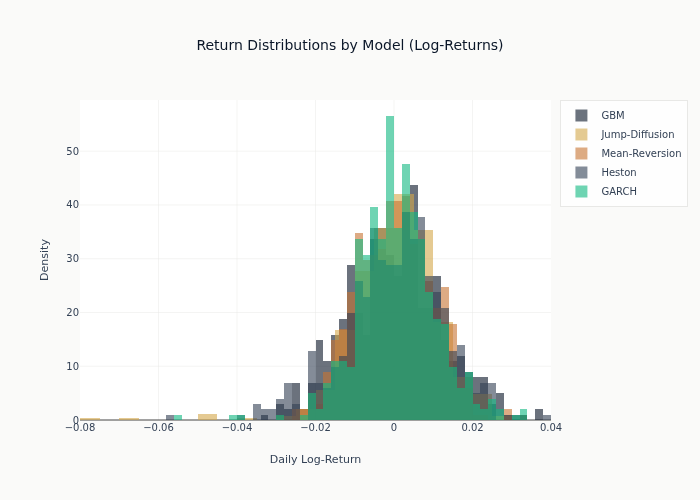

In [26]:
# Return distribution comparison
fig = go.Figure()

for idx, (name, prices) in enumerate(all_models.items()):
    log_returns = np.diff(np.log(prices))
    fig.add_trace(
        go.Histogram(
            x=log_returns,
            name=name,
            opacity=0.6,
            nbinsx=50,
            histnorm="probability density",
            marker_color=colors[idx],
        )
    )

fig.update_layout(
    title="Return Distributions by Model (Log-Returns)",
    xaxis_title="Daily Log-Return",
    yaxis_title="Density",
    barmode="overlay",
)
fig.show()

**Interpretation**: GBM returns are near-Gaussian by construction (zero excess
kurtosis). Jump-diffusion and GARCH produce the heaviest tails, closest to
the empirical leptokurtosis observed in real markets. Heston generates moderate
tail weight through its stochastic volatility channel. Mean-reversion shows a
compressed distribution due to its pull toward equilibrium. For risk management
(VaR, ES), models that understate kurtosis — like plain GBM — systematically
underestimate tail losses.

---
# Part 3: Bootstrap Methods

Bootstrap methods resample historical data rather than assuming a parametric
model. They preserve the **empirical distribution** exactly, including fat tails.

| Method | Block Size | Preserves Autocorrelation | Best For |
|--------|-----------|--------------------------|----------|
| **IID Bootstrap** | 1 | No | i.i.d. assumption OK |
| **Block Bootstrap** | Fixed | Yes (within blocks) | Time series |
| **Stationary Bootstrap** | Random | Yes (smoother) | Financial returns |

### Key Trade-off

- **Parametric**: Can generate scenarios *beyond* historical range
- **Bootstrap**: Preserves empirical distribution *exactly* but limited to observed extremes

### Consistency Note

We bootstrap **log-returns** to match the parametric models above.

## Load Real Data for Bootstrap

In [27]:
# Compute log-returns (consistent with parametric models)
spy_log_returns = np.diff(np.log(spy_close))

print(f"SPY log-returns: {len(spy_log_returns)} observations")
print(f"Mean: {spy_log_returns.mean():.6f}")
print(f"Std: {spy_log_returns.std():.4f}")
print(f"Skewness: {skew(spy_log_returns):.4f}")
print(
    f"Excess kurtosis: {kurtosis(spy_log_returns, fisher=True, bias=False):.4f} (Fisher, Gaussian=0)"
)

SPY log-returns: 5030 observations
Mean: 0.000408
Std: 0.0122
Skewness: -0.3042
Excess kurtosis: 14.3458 (Fisher, Gaussian=0)


## 3.1 IID Bootstrap

The simplest resampling method: draw individual returns **with replacement**.

### Algorithm

```
For each bootstrap sample of length T:
    For t = 1 to T:
        Draw index i uniformly from {1, ..., N}
        Set r*_t = r_i  (original return i)
    Return r* = (r*_1, ..., r*_T)
```

### Properties

- **Preserves marginal distribution**: Same histogram as original
- **Destroys autocorrelation**: Each draw is independent
- **Fast and simple**: No tuning parameters

In [28]:
def iid_bootstrap(
    data: np.ndarray,
    n_samples: int,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate IID bootstrap sample.

    Parameters
    ----------
    data : np.ndarray
        Original data
    n_samples : int
        Length of bootstrap sample
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    np.ndarray
        Bootstrap sample
    """
    if rng is None:
        rng = np.random.default_rng()
    indices = rng.choice(len(data), size=n_samples, replace=True)
    return data[indices]


# Generate one bootstrap sample
iid_rng = np.random.default_rng(50)
iid_sample = iid_bootstrap(spy_log_returns, len(spy_log_returns), rng=iid_rng)

print("IID Bootstrap vs Original (log-returns):")
print(f"  Mean: {iid_sample.mean():.6f} vs {spy_log_returns.mean():.6f}")
print(f"  Std: {iid_sample.std():.4f} vs {spy_log_returns.std():.4f}")
print(f"  Skew: {skew(iid_sample):.4f} vs {skew(spy_log_returns):.4f}")

IID Bootstrap vs Original (log-returns):
  Mean: 0.000341 vs 0.000408
  Std: 0.0124 vs 0.0122
  Skew: -0.6880 vs -0.3042


### Library Usage: IID Bootstrap

In [29]:
bs = IIDBootstrap(spy_log_returns, seed=50)
means = [data[0].mean() for data, _ in bs.bootstrap(100)]
print(f"arch IIDBootstrap (100 samples): mean of means = {np.mean(means):.6f}")

arch IIDBootstrap (100 samples): mean of means = 0.000400


## 3.2 Block Bootstrap

Resample **contiguous blocks** of fixed length to preserve local dependence.

### Algorithm (Moving Block Bootstrap)

```
Choose block length b
For each bootstrap sample of length T:
    While sample length < T:
        Draw start index i uniformly from {1, ..., N-b+1}
        Append block (r_i, r_{i+1}, ..., r_{i+b-1})
    Trim to length T
```

### Block Length Selection

- Rule of thumb: $b \approx T^{1/3}$
- Financial: ~22 days (one month) is common
- Optimal: Cross-validation on out-of-sample statistics

In [30]:
def block_bootstrap(
    data: np.ndarray,
    block_size: int,
    n_samples: int,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate moving block bootstrap sample.

    Parameters
    ----------
    data : np.ndarray
        Original data
    block_size : int
        Fixed block length
    n_samples : int
        Length of bootstrap sample
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    np.ndarray
        Bootstrap sample
    """
    if rng is None:
        rng = np.random.default_rng()

    n = len(data)
    result = []

    while len(result) < n_samples:
        start = rng.integers(0, n - block_size + 1)
        block = data[start : start + block_size]
        result.extend(block)

    return np.array(result[:n_samples])


# Generate block bootstrap sample (22-day blocks)
block_size = 22
block_rng = np.random.default_rng(51)
block_sample = block_bootstrap(spy_log_returns, block_size, len(spy_log_returns), rng=block_rng)

print(f"Block Bootstrap (block_size={block_size}) vs Original:")
print(f"  Mean: {block_sample.mean():.6f} vs {spy_log_returns.mean():.6f}")
print(f"  Std: {block_sample.std():.4f} vs {spy_log_returns.std():.4f}")

Block Bootstrap (block_size=22) vs Original:
  Mean: 0.000321 vs 0.000408
  Std: 0.0127 vs 0.0122


### Library Usage: Block Bootstrap

In [31]:
bs = MovingBlockBootstrap(block_size, spy_log_returns, seed=51)
means = [data[0].mean() for data, _ in bs.bootstrap(100)]
print(f"arch MovingBlockBootstrap (100 samples): mean of means = {np.mean(means):.6f}")

arch MovingBlockBootstrap (100 samples): mean of means = 0.000426


## 3.3 Stationary Bootstrap

Uses **random block lengths** from a geometric distribution, eliminating
artificial block boundaries.

### Algorithm (Politis & Romano 1994)

```
Choose expected block length b
For each bootstrap sample of length T:
    Set t = 0
    While t < T:
        Draw start index i uniformly from {1, ..., N}
        Draw block length L from Geometric(1/b)
        Append (r_i, r_{i+1}, ..., r_{i+L-1}) with wrap-around
        t = t + L
    Trim to length T
```

### Why "Stationary"?

With random block lengths, the bootstrap distribution is **stationary** -
each position in the sample has the same marginal distribution.

In [32]:
def stationary_bootstrap(
    data: np.ndarray,
    expected_block_size: float,
    n_samples: int,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate stationary bootstrap sample.

    Parameters
    ----------
    data : np.ndarray
        Original data
    expected_block_size : float
        Expected block length (geometric distribution parameter)
    n_samples : int
        Length of bootstrap sample
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    np.ndarray
        Bootstrap sample
    """
    if rng is None:
        rng = np.random.default_rng()

    n = len(data)
    p = 1.0 / expected_block_size  # Probability of ending block
    result = []

    while len(result) < n_samples:
        pos = rng.integers(0, n)

        while len(result) < n_samples:
            result.append(data[pos])
            pos = (pos + 1) % n  # Wrap around

            if rng.random() < p:
                break

    return np.array(result[:n_samples])


# Generate stationary bootstrap sample
stat_rng = np.random.default_rng(52)
stat_sample = stationary_bootstrap(spy_log_returns, block_size, len(spy_log_returns), rng=stat_rng)

print(f"Stationary Bootstrap (expected block={block_size}) vs Original:")
print(f"  Mean: {stat_sample.mean():.6f} vs {spy_log_returns.mean():.6f}")
print(f"  Std: {stat_sample.std():.4f} vs {spy_log_returns.std():.4f}")

Stationary Bootstrap (expected block=22) vs Original:
  Mean: 0.000413 vs 0.000408
  Std: 0.0111 vs 0.0122


### Library Usage: Stationary Bootstrap

In [33]:
bs = StationaryBootstrap(block_size, spy_log_returns, seed=52)
means = [data[0].mean() for data, _ in bs.bootstrap(100)]
print(f"arch StationaryBootstrap (100 samples): mean of means = {np.mean(means):.6f}")

arch StationaryBootstrap (100 samples): mean of means = 0.000401


## Bootstrap Method Comparison

In [34]:
# Collect bootstrap samples
bootstrap_samples = {
    "Original": spy_log_returns,
    "IID": iid_sample,
    "Block": block_sample,
    "Stationary": stat_sample,
}

# Compare moments
bootstrap_stats = []
for name, sample in bootstrap_samples.items():
    bootstrap_stats.append(
        {
            "method": name,
            "mean": sample.mean(),
            "std": sample.std(),
            "skew": skew(sample),
            "excess_kurtosis": kurtosis(sample, fisher=True, bias=False),
        }
    )

pl.DataFrame(bootstrap_stats)

method,mean,std,skew,excess_kurtosis
str,f64,f64,f64,f64
"""Original""",0.000408,0.01222,-0.304239,14.345821
"""IID""",0.000341,0.012435,-0.687978,12.397964
"""Block""",0.000321,0.012722,0.251989,18.360753
"""Stationary""",0.000413,0.011101,-0.446737,13.644643


## Autocorrelation Preservation

The key difference between bootstrap methods is how they handle **temporal
dependence**. We measure this via autocorrelation of **squared returns**
(signature of volatility clustering).

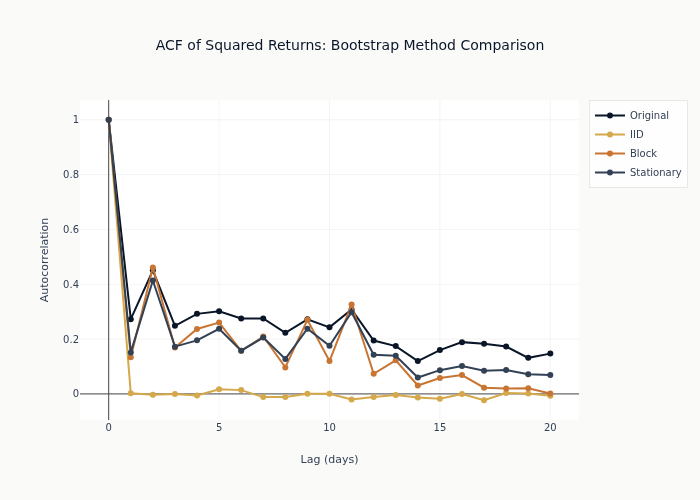

In [35]:
# Compute ACF for squared returns
n_lags = 20
fig = go.Figure()

bootstrap_colors = [COLORS["blue"], COLORS["amber"], COLORS["copper"], COLORS["neutral"]]

for idx, (name, sample) in enumerate(bootstrap_samples.items()):
    squared = sample**2
    acf_values = acf(squared, nlags=n_lags, fft=True)
    fig.add_trace(
        go.Scatter(
            x=list(range(n_lags + 1)),
            y=acf_values,
            mode="lines+markers",
            name=name,
            line=dict(color=bootstrap_colors[idx]),
        )
    )

fig.update_layout(
    title="ACF of Squared Returns: Bootstrap Method Comparison",
    xaxis_title="Lag (days)",
    yaxis_title="Autocorrelation",
)
fig.show()

### Bootstrap Key Takeaways

1. **IID Bootstrap**: Simple and fast, but **destroys** temporal dependence
2. **Block Bootstrap**: Preserves autocorrelation **within** blocks, has boundary artifacts
3. **Stationary Bootstrap**: Random blocks = **smoother** preservation of dependence

For financial returns with volatility clustering, prefer **Block** or
**Stationary** bootstrap. The ACF of squared returns shows preservation quality.

---
# Part 4: Model Comparison Summary

## What Each Method Captures

| Method | Fat Tails | Volatility Clustering | Beyond History |
|--------|----------|----------------------|----------------|
| GBM | No | No | Yes |
| Jump-Diffusion | Yes | No | Yes |
| Mean-Reversion | No | Negative autocorr | Yes |
| Heston | Yes | Yes | Yes |
| GARCH | Yes | Yes | Yes |
| IID Bootstrap | Yes | No | No |
| Block Bootstrap | Yes | Partial | No |
| Stationary Bootstrap | Yes | Yes | No |

## Key Takeaways

1. **Parametric models** (GBM, Jump-Diffusion, Heston, GARCH) can generate scenarios
   beyond historical experience but require choosing or calibrating parameters
2. **Bootstrap methods** (IID, Block, Stationary) preserve the empirical distribution
   exactly but cannot produce extremes not seen in the original data
3. **No classical model captures all stylized facts**: Heston and GARCH come closest
   with fat tails and volatility clustering, but miss higher-order dependencies
4. **Drift compensation** (Jump-Diffusion) and **full truncation** (Heston) are
   critical implementation details that affect simulation correctness
5. **GARCH calibration** via MLE bridges the gap between assumed and observed dynamics,
   producing more realistic volatility paths than fixed-parameter models

**Next**: See [`01_timegan`](01_timegan.ipynb) for the first learned generative model, which uses
adversarial training to capture temporal dynamics that classical models miss.

**Book**: Chapter 5, Section 5.2 covers the generative model taxonomy and explains
why learned models complement (rather than replace) classical simulation.